StatementMeta(yudhaesparkpool, 2, 70, Finished, Available, Finished, False)

 VISUALISASI DISTRIBUSI SKOR POTENSI


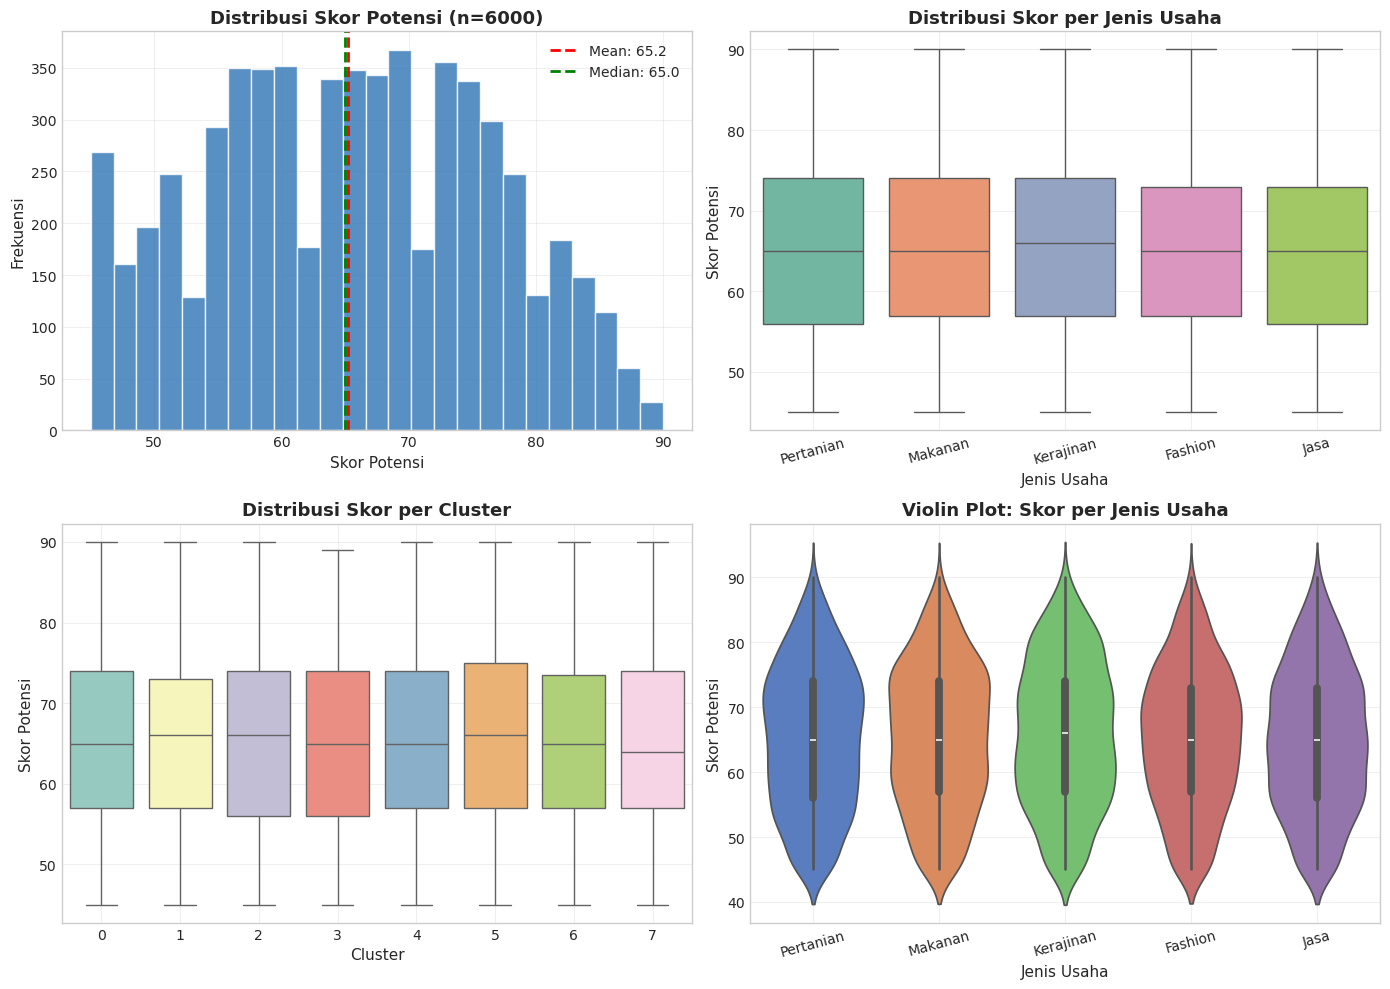


 STATISTIK DESKRIPTIF SKOR POTENSI
count    6000.000000
mean       65.235500
std        10.971027
min        45.000000
25%        57.000000
50%        65.000000
75%        74.000000
max        90.000000
Name: skor_potensi, dtype: float64

>>> Rata-rata Skor per Jenis Usaha:
jenis_usaha
Kerajinan    65.748936
Pertanian    65.249593
Makanan      65.210957
Fashion      65.053708
Jasa         64.920767
Name: skor_potensi, dtype: float64

>>> Rata-rata Skor per Cluster:
cluster
0    65.439946
5    65.402906
2    65.325645
6    65.318608
3    65.261111
7    65.097625
1    65.093708
4    64.964691
Name: skor_potensi, dtype: float64


In [63]:
# === VISUALISASI DISTRIBUSI SKOR POTENSI (FIXED) ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# Load data
df = spark.read.parquet("/lakehouse/default/Files/umkm_v3_final")
pdf = df.select("skor_potensi", "jenis_usaha", "cluster").toPandas()

print("="*70)
print(" VISUALISASI DISTRIBUSI SKOR POTENSI")
print("="*70)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram Distribusi Skor
ax1 = axes[0, 0]
ax1.hist(pdf['skor_potensi'], bins=25, color='#2E75B6', edgecolor='white', alpha=0.8)
ax1.axvline(pdf['skor_potensi'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {pdf["skor_potensi"].mean():.1f}')
ax1.axvline(pdf['skor_potensi'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {pdf["skor_potensi"].median():.1f}')
ax1.set_xlabel('Skor Potensi', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_title('Distribusi Skor Potensi (n=6000)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box Plot per Jenis Usaha
ax2 = axes[0, 1]
sns.boxplot(data=pdf, x='jenis_usaha', y='skor_potensi', ax=ax2, palette='Set2')
ax2.set_xlabel('Jenis Usaha', fontsize=11)
ax2.set_ylabel('Skor Potensi', fontsize=11)
ax2.set_title('Distribusi Skor per Jenis Usaha', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3)

# 3. Box Plot per Cluster
ax3 = axes[1, 0]
sns.boxplot(data=pdf, x='cluster', y='skor_potensi', ax=ax3, palette='Set3')
ax3.set_xlabel('Cluster', fontsize=11)
ax3.set_ylabel('Skor Potensi', fontsize=11)
ax3.set_title('Distribusi Skor per Cluster', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Violin Plot per Jenis Usaha
ax4 = axes[1, 1]
sns.violinplot(data=pdf, x='jenis_usaha', y='skor_potensi', ax=ax4, palette='muted')
ax4.set_xlabel('Jenis Usaha', fontsize=11)
ax4.set_ylabel('Skor Potensi', fontsize=11)
ax4.set_title('Violin Plot: Skor per Jenis Usaha', fontsize=13, fontweight='bold')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistik Deskriptif
print("\n" + "="*70)
print(" STATISTIK DESKRIPTIF SKOR POTENSI")
print("="*70)
print(pdf['skor_potensi'].describe())

print("\n>>> Rata-rata Skor per Jenis Usaha:")
print(pdf.groupby('jenis_usaha')['skor_potensi'].mean().sort_values(ascending=False))

print("\n>>> Rata-rata Skor per Cluster:")
print(pdf.groupby('cluster')['skor_potensi'].mean().sort_values(ascending=False))